# Importing Primary Libraries

In [1]:
import numpy as np 
import pandas as pd 

/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Load Dataset

In [2]:
matches = pd.read_csv("../data/processed/matches.csv")

In [3]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 23346 entries, 0 to 23345
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      23346 non-null  str    
 1   home_team                 23346 non-null  str    
 2   away_team                 23346 non-null  str    
 3   home_score                23346 non-null  int64  
 4   away_score                23346 non-null  int64  
 5   goal_diff                 23346 non-null  int64  
 6   tournament                23346 non-null  str    
 7   country                   23346 non-null  str    
 8   neutral                   23346 non-null  bool   
 9   host_advantage            23346 non-null  int64  
 10  elo_diff                  23346 non-null  float64
 11  abs_elo_diff              23346 non-null  float64
 12  home_recent_win_rate      23346 non-null  float64
 13  away_recent_win_rate      23346 non-null  float64
 14  recent_form_diff 

# Preparation

## Define features and target

In [4]:
feature_cols = [
    "neutral",
    "host_advantage",
    "elo_diff",
    "abs_elo_diff",
    "recent_form_diff",
    "abs_recent_form_diff",
    "home_recent_draw_rate",
    "away_recent_draw_rate",
    "recent_draw_diff",
    "abs_recent_draw_diff",
    "home_avg_goals_last10",
    "away_avg_goals_last10",
    "diff_in_avg_goals",
    "home_avg_conceded_last10",
    "away_avg_conceded_last10",
    "diff_in_avg_conceded",
    "tournament_weight"
]

target = "match_result"

X = matches[feature_cols]
y = matches[target]

# Train-test Split

Time-based Split

In [5]:
matches["date"] = pd.to_datetime(matches["date"])
split_date = "2022-12-19"
train = matches[matches["date"] < split_date]
test = matches[matches["date"] >= split_date]

# Checking train-test split ratio
print(len(train)/len(matches)*100)

85.41077700676776


~85% of the daata is the training set

In [6]:
# Preparing train and test sets
X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print(f"Training set: {len(train)} matches")
print(f"Test set: {len(test)} matches")
print(f"\nTarget distribution:\n{y_train.value_counts(normalize=True)}")

Training set: 19940 matches
Test set: 3406 matches

Target distribution:
match_result
home_win    0.483300
away_win    0.280542
draw        0.236158
Name: proportion, dtype: float64


In [7]:
y_test.value_counts(normalize=True)

match_result
home_win    0.472695
away_win    0.293306
draw        0.233999
Name: proportion, dtype: float64

There is class imbalance as the proportion of draws and away team wins are much lower than that of home team wins. Draws especially, are easily ignored in football prediction models.

## Encoding

In [8]:
# Encode target labels for XGBoost, which requires numeric labels for multi-class classification
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Label encoding: {'away_win': 0, 'draw': 1, 'home_win': 2}


# Model Training

Three models are explored in this project: Logistic Regression (baseline), Random Forest and XGBoost.

## Logistic Regression

Logistic Regression serves as the baseline model for this prediction project.

In [9]:
# Standardise the training and test data
from sklearn.preprocessing import StandardScaler
std_x = StandardScaler()
X_train_scaled = std_x.fit_transform(X_train)
X_test_scaled = std_x.transform(X_test)

Logistic Regression before hyperparameter tuning

In [10]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import balanced_accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print("\n--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))


--- Logistic Regression ---
Accuracy: 0.5602
Balanced Accuracy: 0.5201
              precision    recall  f1-score   support

    away_win       0.56      0.63      0.60       999
        draw       0.28      0.27      0.27       797
    home_win       0.70      0.66      0.68      1610

    accuracy                           0.56      3406
   macro avg       0.51      0.52      0.52      3406
weighted avg       0.56      0.56      0.56      3406



In [11]:
from sklearn.model_selection import RandomizedSearchCV
lr_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],               
    "solver": ["liblinear", "saga"],
    "class_weight": [None, "balanced"]
}

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    n_iter=20,
    cv=tscv,
    scoring="f1_macro", # macro-averaged F1 score to account for class imbalance
    random_state=42,
    n_jobs=-1 # use all available CPU cores for faster search
)
lr_search.fit(X_train_scaled, y_train)
print(lr_search.best_params_)

/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/edenaong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/edenaong/

{'solver': 'saga', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 10}


/Users/edenaong/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression after hyperparameter tuning

In [12]:
best_lr = lr_search.best_estimator_
best_lr.fit(X_train_scaled, y_train)
lr_best_preds = best_lr.predict(X_test_scaled)

print("\n--- Logistic Regression (Best Hyperparameters) ---")
print(f"Accuracy: {accuracy_score(y_test, lr_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, lr_best_preds):.4f}")
print(classification_report(y_test, lr_best_preds))


--- Logistic Regression (Best Hyperparameters) ---
Accuracy: 0.5599
Balanced Accuracy: 0.5196
              precision    recall  f1-score   support

    away_win       0.56      0.63      0.59       999
        draw       0.28      0.27      0.27       797
    home_win       0.69      0.66      0.68      1610

    accuracy                           0.56      3406
   macro avg       0.51      0.52      0.52      3406
weighted avg       0.56      0.56      0.56      3406



/Users/edenaong/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Comparison of Logistic Regression performance before and after hyperparameter tuning

In [13]:
print("\n--- Baseline Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, lr_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, lr_preds, output_dict=True)['macro avg']['f1-score']:.4f}")
print("\n--- Optimised Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, lr_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, lr_best_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, lr_best_preds, output_dict=True)['macro avg']['f1-score']:.4f}")


--- Baseline Logistic Regression ---
Accuracy: 0.5602
Balanced Accuracy: 0.5201
Macro F1 Score: 0.5156

--- Optimised Logistic Regression ---
Accuracy: 0.5599
Balanced Accuracy: 0.5196
Macro F1 Score: 0.5152


## Random Forest

Random Forest before hyperparameter tuning

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", max_depth=5)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("\n--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, rf_preds):.4f}")


--- Random Forest ---
Accuracy: 0.5696
              precision    recall  f1-score   support

    away_win       0.56      0.64      0.60       999
        draw       0.28      0.24      0.26       797
    home_win       0.70      0.69      0.69      1610

    accuracy                           0.57      3406
   macro avg       0.51      0.52      0.52      3406
weighted avg       0.56      0.57      0.56      3406

Balanced Accuracy: 0.5234


In [15]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],       # None = unlimited depth
    "min_samples_split": [2, 5, 10],    # minimum samples to split a node
    "min_samples_leaf": [1, 2, 4],      # minimum samples at leaf node
    "max_features": ["sqrt", "log2"],    # number of features to consider at each split
    "class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,
    cv=tscv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(rf_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced'}


Random Forest after hyperparameter tuning

In [16]:
best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)
rf_best_preds = best_rf.predict(X_test)

print("\n--- Random Forest (Best Hyperparameters) ---")
print(f"Accuracy: {accuracy_score(y_test, rf_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, rf_best_preds):.4f}")
print(classification_report(y_test, rf_best_preds))


--- Random Forest (Best Hyperparameters) ---
Accuracy: 0.5716
Balanced Accuracy: 0.5254
              precision    recall  f1-score   support

    away_win       0.57      0.64      0.60       999
        draw       0.29      0.25      0.27       797
    home_win       0.70      0.69      0.69      1610

    accuracy                           0.57      3406
   macro avg       0.52      0.53      0.52      3406
weighted avg       0.56      0.57      0.57      3406



Comparison of Random Forest performance before and after hyperparameter tuning

In [17]:
print("\n--- Baseline Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, rf_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, rf_preds, output_dict=True)['macro avg']['f1-score']:.4f}")
print("\n--- Optimised Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, rf_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, rf_best_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, rf_best_preds, output_dict=True)['macro avg']['f1-score']:.4f}")


--- Baseline Random Forest ---
Accuracy: 0.5696
Balanced Accuracy: 0.5234
Macro F1 Score: 0.5177

--- Optimised Random Forest ---
Accuracy: 0.5716
Balanced Accuracy: 0.5254
Macro F1 Score: 0.5198


## XGBoost

XGBoost before hyperparameter tuning

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss") # mlogloss is used for multi-class classification
xgb.fit(X_train, y_train_encoded)
xgb_preds = le.inverse_transform(xgb.predict(X_test))
print("\n--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))


--- XGBoost ---
Accuracy: 0.5822
Balanced Accuracy: 0.4980
              precision    recall  f1-score   support

    away_win       0.57      0.58      0.57       999
        draw       0.29      0.08      0.13       797
    home_win       0.62      0.83      0.71      1610

    accuracy                           0.58      3406
   macro avg       0.49      0.50      0.47      3406
weighted avg       0.53      0.58      0.53      3406



Hyperparameter Tuning for XGBoost

In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    n_iter=20,
    cv=tscv,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_encoded)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gam...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1_macro')

In [20]:
search.best_params_

{'subsample': 0.7,
 'n_estimators': 300,
 'max_depth': 4,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [21]:
# Cross-validation results on the training set
search.best_score_ 

0.45966411962549386

XGBoost after hyperparameter tuning

In [22]:
best_xgb = search.best_estimator_
best_xgb.fit(X_train, y_train_encoded)
xgb_best_preds = le.inverse_transform(best_xgb.predict(X_test))

print("\n--- XGBoost (Best Hyperparameters) ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_best_preds):.4f}")
print(classification_report(y_test, xgb_best_preds))


--- XGBoost (Best Hyperparameters) ---
Accuracy: 0.5978
Balanced Accuracy: 0.5059
              precision    recall  f1-score   support

    away_win       0.58      0.62      0.60       999
        draw       0.31      0.04      0.07       797
    home_win       0.62      0.86      0.72      1610

    accuracy                           0.60      3406
   macro avg       0.50      0.51      0.46      3406
weighted avg       0.53      0.60      0.53      3406



In [23]:
print("\n--- Baseline XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, xgb_preds, output_dict=True)['macro avg']['f1-score']:.4f}")
print("\n--- Optimised XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_best_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_best_preds):.4f}")
print(f"Macro F1 Score: {classification_report(y_test, xgb_best_preds, output_dict=True)['macro avg']['f1-score']:.4f}")


--- Baseline XGBoost ---
Accuracy: 0.5822
Balanced Accuracy: 0.4980
Macro F1 Score: 0.4705

--- Optimised XGBoost ---
Accuracy: 0.5978
Balanced Accuracy: 0.5059
Macro F1 Score: 0.4619


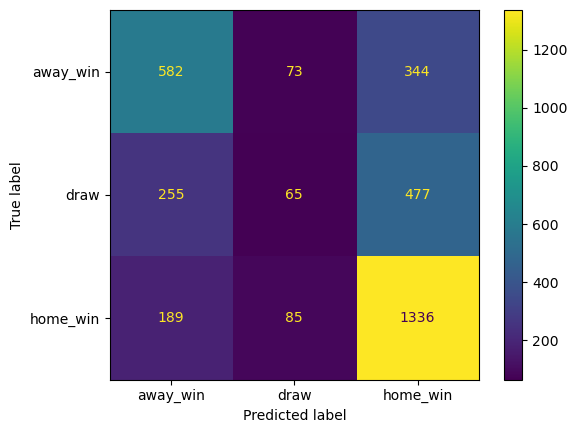

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,xgb_preds)

## Feature Importance

In [25]:
lr_feature_importance = pd.Series(
    np.abs(lr.coef_).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print(lr_feature_importance)

elo_diff                    0.399325
neutral                     0.142820
host_advantage              0.142450
diff_in_avg_conceded        0.114045
home_avg_conceded_last10    0.103972
away_avg_conceded_last10    0.099706
recent_form_diff            0.099485
away_avg_goals_last10       0.048434
diff_in_avg_goals           0.046054
tournament_weight           0.034810
abs_recent_draw_diff        0.028163
home_avg_goals_last10       0.026451
abs_elo_diff                0.013947
abs_recent_form_diff        0.012282
recent_draw_diff            0.010071
home_recent_draw_rate       0.006990
away_recent_draw_rate       0.006643
dtype: float64


In [26]:
pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

elo_diff                    0.436384
diff_in_avg_conceded        0.152127
abs_elo_diff                0.089318
recent_form_diff            0.070750
diff_in_avg_goals           0.066510
home_avg_conceded_last10    0.052433
away_avg_conceded_last10    0.042657
away_avg_goals_last10       0.017368
neutral                     0.013121
host_advantage              0.013040
home_avg_goals_last10       0.011441
tournament_weight           0.010153
abs_recent_form_diff        0.008988
recent_draw_diff            0.006806
home_recent_draw_rate       0.004068
away_recent_draw_rate       0.003100
abs_recent_draw_diff        0.001736
dtype: float64

In [27]:
pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

elo_diff                    0.180711
host_advantage              0.145168
neutral                     0.075623
abs_elo_diff                0.062224
diff_in_avg_conceded        0.053013
abs_recent_form_diff        0.047806
tournament_weight           0.047050
home_avg_conceded_last10    0.045279
away_avg_conceded_last10    0.040783
abs_recent_draw_diff        0.039121
recent_draw_diff            0.038918
away_avg_goals_last10       0.038593
home_avg_goals_last10       0.038373
diff_in_avg_goals           0.037738
recent_form_diff            0.037336
home_recent_draw_rate       0.036241
away_recent_draw_rate       0.036024
dtype: float32

Across all 3 models,
- elo_diff displays the greatest feature importance.
- host_advantage and diff_in_avg_conceded are consistently important features.
- Draw related features added to improve prediction of draws do not contribute much to prediction performance.

# Model Comparison

The models that produced the best result for Macro F1 score are chosen to be displayed.

In [28]:
from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_best_preds),
        accuracy_score(y_test, rf_best_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    "Macro F1": [
        f1_score(y_test, lr_best_preds, average="macro"),
        f1_score(y_test, rf_best_preds, average="macro"),
        f1_score(y_test, xgb_preds, average="macro")
    ],
    "Weighted F1": [
        f1_score(y_test, lr_best_preds, average="weighted"),
        f1_score(y_test, rf_best_preds, average="weighted"),
        f1_score(y_test, xgb_preds, average="weighted")
    ]
})

results = results.round(4)

results

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.5599,0.5152,0.5585
1,Random Forest,0.5716,0.5198,0.5660
2,XGBoost,0.5822,0.4705,0.5337


XGBoost achieved the highest prediction accuracy (58.22%), while Random Forest achieved the highest Macro F1 score (51.98%). and weighted F1 score (56.60%).The Macro F1 score is chosen as the most important metric, as it treats all 3 classes equally. Since the World Cup simulation requires realistic prediction of all three match outcomes (home win, draw, away win), the Random Forest model is selected as the final model due to its highest performance in the Macro F1 score, thus demonstrating the most balanced performance across classes.

In [29]:
best_model = rf

import joblib
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']